# Phase 3 : Shape Optimization with the Surrogate

**Project:** A data-driven surrogate for airfoil shape optimization, built on the AirfRANS benchmark

**Author:** Muhammad Uns Haider Shah

## Objective
Drive airfoil shape optimization with the direct force surrogates of Phase 2b, and compare two ways of searching the design space:

* **Gradient-free:** Bayesian optimization, treating each surrogate call as an expensive evaluation, with a random-search control at the same budget.
* **Gradient-based:** the surrogate is a neural network, so the design sensitivities $\partial C_L/\partial \mathbf{x}$ and $\partial C_D/\partial \mathbf{x}$ follow from automatic differentiation through the network and through the shape parameterisation. No adjoint solver and no finite differences.

Both search the **same** objective, the neural-network ensemble, so the comparison isolates the search strategy. The Gaussian process then provides an independent second opinion on the optima, and its predictive variance says how much confidence is warranted.

## Design space
NACA 4-digit airfoils: maximum camber $M$ (% chord), its position $P$ (tenths of chord), and thickness $XX$ (% chord). Bounds are taken from the 4-digit training cases, so the optimizer stays inside the region the surrogate was trained on. A **minimum thickness of 12 %** is imposed, as a stand-in for the structural requirement any real design carries, and because Phase 2b showed the surrogate is unreliable for very thin sections.

## Optimization problems
1. **Maximise $L/D$** at fixed $Re = 4\times10^6$ and $\alpha = 4°$. Variables: $M, P, XX$.
2. **Minimise $C_D$ subject to $C_L \ge 0.8$** at fixed $Re = 4\times10^6$, with $\alpha$ free. Variables: $M, P, XX, \alpha$. This is the standard aerodynamic formulation: the angle adjusts to meet the lift requirement.

A dense random sample of the design space provides the surrogate's own optimum as a reference, which separates *search* error from *surrogate* error.

**Runtime:** Google Colab (GPU optional). Requires the Phase 1b and 2b outputs on Drive.

## 1. Environment

In [ ]:
# pyvista is pinned: 0.49+ requires a newer IPython than the Colab runtime provides
!pip install -q airfrans "pyvista==0.48.0" "vtk<9.7"
import airfrans as af
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch, torch.nn as nn
import os, glob, json, time, gc

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE, '|', torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'NO GPU: change the runtime type')
from scipy.spatial import cKDTree
from scipy.stats import spearmanr
from airfrans.naca_generator import camber_line, naca_generator
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from scipy.optimize import minimize
from scipy.stats import qmc, norm
from airfrans.naca_generator import naca_generator, camber_line
import joblib, warnings

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 43.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.0/146.0 MB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.7/242.7 kB 14.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.0/273.0 kB 12.9 MB/s eta 0:00:00
device: cuda | Tesla T4


## 2. Configuration

In [ ]:
OPT = dict(
    seed        = 0,
    re          = 4.0e6,       # fixed operating Reynolds number
    aoa_p1      = 4.0,         # fixed incidence, problem 1
    cl_target   = 0.8,         # lift requirement, problem 2
    t_min       = 12.0,        # minimum thickness (% chord)
    aoa_bounds  = (-5.0, 15.0),
    n_init      = 10,          # Bayesian optimization: initial design
    n_bo        = 40,          # Bayesian optimization: sequential evaluations
    n_starts    = 20,          # gradient-based: multi-start count
    n_reference = 200_000,     # random sample used as the surrogate's own optimum
)
np.random.seed(OPT['seed']); torch.manual_seed(OPT['seed'])

## 3. Dataset and Phase 1b / 2b artefacts

In [ ]:
import shutil, zipfile
from google.colab import drive

USE_DRIVE = True
DRIVE_DIR = '/content/drive/MyDrive/airfrans'
DRIVE_ZIP = f'{DRIVE_DIR}/Dataset.zip'
ROOT_DL   = '/content/airfrans_data'
LOCAL_ZIP = f'{ROOT_DL}/Dataset.zip'

def have_data():
    return bool(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True))

def gb(path):
    return os.path.getsize(path) / 1e9

if USE_DRIVE:
    drive.mount('/content/drive')
    os.makedirs(DRIVE_DIR, exist_ok=True)
os.makedirs(ROOT_DL, exist_ok=True)

if have_data():
    print('Dataset already extracted on this machine.')
elif USE_DRIVE and os.path.exists(DRIVE_ZIP):
    print(f'Copying {gb(DRIVE_ZIP):.1f} GB zip from Drive (unzipping from local disk is much faster)...')
    shutil.copy(DRIVE_ZIP, LOCAL_ZIP)
    print('Unzipping...')
    with zipfile.ZipFile(LOCAL_ZIP) as z:
        z.extractall(ROOT_DL)
else:
    print('No cached copy found. Downloading from the AirfRANS server (slow, one time only)...')
    af.dataset.download(root=ROOT_DL, file_name='Dataset', unzip=True, OpenFOAM=False)

# Cache to Drive if it isn't there yet. This only runs after a successful unzip,
# so a broken or partial download never gets saved.
if USE_DRIVE and os.path.exists(LOCAL_ZIP) and have_data():
    if not os.path.exists(DRIVE_ZIP) or gb(DRIVE_ZIP) != gb(LOCAL_ZIP):
        print(f'Saving {gb(LOCAL_ZIP):.1f} GB zip to Drive (10-20 min, one time only)...')
        shutil.copy(LOCAL_ZIP, DRIVE_ZIP)
    print(f'Drive copy OK: {gb(DRIVE_ZIP):.2f} GB  (local {gb(LOCAL_ZIP):.2f} GB)')

print('Data ready:', have_data())

Mounted at /content/drive
Copying 10.0 GB zip from Drive (unzipping from local disk is much faster)...
Unzipping...
Drive copy OK: 10.03 GB  (local 10.03 GB)
Data ready: True


In [ ]:
# The loader needs the folder that contains manifest.json. Find it rather than guessing.
ROOT = os.path.dirname(glob.glob(f'{ROOT_DL}/**/manifest.json', recursive=True)[0])
print('Dataset root:', ROOT)

# Free disk space: the zip is no longer needed locally once extracted
zip_path = f'{ROOT_DL}/Dataset.zip'
if os.path.exists(zip_path):
    os.remove(zip_path)

with open(f'{ROOT}/manifest.json') as f:
    manifest = json.load(f)
for k, v in manifest.items():
    print(f'{k:15s} {len(v):5d} simulations')

Dataset root: /content/airfrans_data/Dataset
full_train        800 simulations
scarce_train      200 simulations
reynolds_train    504 simulations
aoa_train         804 simulations
full_test         200 simulations
reynolds_test     496 simulations
aoa_test          196 simulations


In [ ]:
import numpy as np

def order_surface(pos, normals):
    """Return indices that walk the airfoil surface as a closed loop:
    upper surface leading edge -> trailing edge, then lower surface trailing edge -> leading edge.
    Works whichever way the normals point (inward or outward)."""
    g1 = np.where(normals[:, 1] < 0)[0]
    g2 = np.where(normals[:, 1] >= 0)[0]
    # The upper-surface group is the one sitting higher on average
    upper, lower = (g1, g2) if pos[g1, 1].mean() > pos[g2, 1].mean() else (g2, g1)
    upper = upper[np.argsort(pos[upper, 0])]     # LE -> TE
    lower = lower[np.argsort(-pos[lower, 0])]    # TE -> LE
    return np.concatenate([upper, lower]), len(upper)

def pressure_force_coefficients(pos, normals, p, u_inf, aoa_rad):
    """Integrate surface pressure (kinematic, p/rho) to pressure-only lift and drag coefficients.
    pos, normals, p: surface nodes only. Returns (cd_p, cl_p)."""
    idx, _ = order_surface(pos, normals)
    P, N, pp = pos[idx], normals[idx], p[idx].ravel()
    # Length "owned" by each node = half of each neighbouring segment on the closed loop
    seg = np.linalg.norm(np.roll(P, -1, axis=0) - P, axis=1)
    L = 0.5 * (seg + np.roll(seg, 1))
    # Make normals point OUT of the body: on average they should point away from the centroid
    sign = np.sign(np.mean(np.sum((P - P.mean(axis=0)) * N, axis=1)))
    n_out = sign * N / np.linalg.norm(N, axis=1, keepdims=True)
    F = -(pp[:, None] * n_out * L[:, None]).sum(axis=0)       # force / rho
    drag_dir = np.array([np.cos(aoa_rad), np.sin(aoa_rad)])
    lift_dir = np.array([-np.sin(aoa_rad), np.cos(aoa_rad)])
    q = 0.5 * u_inf**2
    return F @ drag_dir / q, F @ lift_dir / q

def parse_name(name):
    """AirfRANS names look like airFoil2D_SST_<Uinf>_<AoA deg>_<NACA params...>"""
    parts = name.split('_')
    u_inf, aoa = float(parts[2]), float(parts[3])
    naca = [float(v) for v in parts[4:]]
    return u_inf, aoa, naca


In [ ]:
P1_DIR  = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase1')
P2B_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase2b')
OUT_DIR = os.path.join(DRIVE_DIR if USE_DRIVE else '/content', 'phase3')
os.makedirs(OUT_DIR, exist_ok=True)

ens_ck = torch.load(f'{P2B_DIR}/force_ensemble.pt', map_location=DEVICE, weights_only=False)
gp_ck  = joblib.load(f'{P2B_DIR}/force_gp.joblib')
STATIONS = np.array(ens_ck['stations'])
G_NAMES = ['t'] + [f'yc@{x:g}' for x in STATIONS]
IN_NAMES = G_NAMES + ['aoa', 're_M']
S = {k: np.array(v) for k, v in ens_ck['stats'].items() if k in ('xm', 'xs', 'ym', 'ys')}
train_forces = pd.read_csv(f'{P2B_DIR}/train_forces.csv')
with open(f'{P1_DIR}/phase1_summary.json') as f:
    VAL_NAMES = set(json.load(f)['val_names'])
print('inputs:', IN_NAMES)
print(f"ensemble: {len(ens_ck['states'])} members, width {ens_ck['width']}")

inputs: ['t', 'yc@0.025', 'yc@0.05', 'yc@0.1', 'yc@0.2', 'yc@0.3', 'yc@0.4', 'yc@0.5', 'yc@0.6', 'yc@0.7', 'yc@0.8', 'yc@0.9', 'yc@0.95', 'aoa', 're_M']
ensemble: 10 members, width 64


## 4. Differentiable parameterisation
The surrogate takes the 13-number shape descriptor, so optimization over $(M, P, XX)$ requires the descriptor as a differentiable function of the design variables. The 4-digit camber line is

$$y_c(x) = \begin{cases} \dfrac{m}{p^2}\left(2px - x^2\right), & x < p \\[2mm] \dfrac{m}{(1-p)^2}\left((1-2p) + 2px - x^2\right), & x \ge p \end{cases}
\qquad m = M/100,\quad p = P/10 .$$

It is implemented in PyTorch below and checked against the `airfrans` implementation.

In [ ]:
ST = torch.tensor(STATIONS, dtype=torch.float64, device=DEVICE)

def descriptor_torch(design):
    # design: (..., 3) = [M (% chord), P (tenths), XX (% chord)] -> (..., 13) descriptor
    M, P, XX = design[..., 0:1], design[..., 1:2], design[..., 2:3]
    m, p, t = M / 100, P / 10, XX / 100
    x = ST.expand(*design.shape[:-1], len(ST))
    fore = (m / p ** 2) * (2 * p * x - x ** 2)
    aft = (m / (1 - p) ** 2) * ((1 - 2 * p) + 2 * p * x - x ** 2)
    y_c = torch.where(x < p, fore, aft)
    return torch.cat([t, y_c], dim=-1)

rng = np.random.default_rng(0)
chk = rng.uniform([0.1, 1.5, 6], [7, 7, 20], size=(200, 3))
mine = descriptor_torch(torch.tensor(chk, dtype=torch.float64, device=DEVICE)).cpu().numpy()
theirs = np.stack([np.r_[d[2] / 100, camber_line(d[:2], STATIONS.copy())[0]] for d in chk])
print(f'max deviation from the airfrans camber line: {np.abs(mine - theirs).max():.2e}')
assert np.abs(mine - theirs).max() < 1e-10

max deviation from the airfrans camber line: 6.94e-17


## 5. Surrogates as design functions
Both surrogates are wrapped as functions of the design vector. The ensemble version is differentiable end to end (design → descriptor → network → $C_L$, $\log C_D$); the Gaussian process version also returns predictive standard deviations.

In [ ]:
class ForceMLP(nn.Module):
    def __init__(self, n_in, width):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(n_in, width), nn.SiLU(),
                                 nn.Linear(width, width), nn.SiLU(),
                                 nn.Linear(width, 2))
    def forward(self, x):
        return self.net(x)

ensemble = []
for st in ens_ck['states']:
    net = ForceMLP(len(IN_NAMES), ens_ck['width']).to(DEVICE).double()
    net.load_state_dict({k: v.double() for k, v in st.items()}); net.eval()
    ensemble.append(net)

xm, xs = (torch.tensor(S[k], dtype=torch.float64, device=DEVICE) for k in ('xm', 'xs'))
ym, ys = (torch.tensor(S[k], dtype=torch.float64, device=DEVICE) for k in ('ym', 'ys'))

def nn_forces(design, aoa, re=None):
    # design: (n, 3) tensor; aoa: (n, 1) tensor; returns CL, CD (tensors, differentiable)
    re = OPT['re'] if re is None else re
    g = descriptor_torch(design)
    re_col = torch.full_like(aoa, re / 1e6)
    X = (torch.cat([g, aoa, re_col], dim=-1) - xm) / xs
    P = torch.stack([net(X) for net in ensemble]).mean(0) * ys + ym
    return P[..., 0], torch.exp(P[..., 1])

def nn_np(x, aoa=None):
    # numpy interface: x = (n, 3) designs (+ aoa column if aoa is None)
    x = np.atleast_2d(x)
    d = torch.tensor(x[:, :3], dtype=torch.float64, device=DEVICE)
    a = torch.tensor(x[:, 3:4] if aoa is None else np.full((len(x), 1), aoa),
                     dtype=torch.float64, device=DEVICE)
    with torch.no_grad():
        cl, cd = nn_forces(d, a)
    return cl.cpu().numpy(), cd.cpu().numpy()

def gp_np(x, aoa=None):
    # Gaussian process: returns CL, CD and their standard deviations (log CD sd for drag)
    x = np.atleast_2d(x)
    g = np.stack([np.r_[d[2] / 100, camber_line(d[:2], STATIONS.copy())[0]] for d in x[:, :3]])
    a = x[:, 3:4] if aoa is None else np.full((len(x), 1), aoa)
    X = (np.hstack([g, a, np.full((len(x), 1), OPT['re'] / 1e6)]) - S['xm']) / S['xs']
    mu, sd = [], []
    for k, gp in enumerate(gp_ck['gps']):
        m, s = gp.predict(X, return_std=True)
        mu.append(m * S['ys'][k] + S['ym'][k]); sd.append(s * S['ys'][k])
    return mu[0], np.exp(mu[1]), sd[0], sd[1]

def grad_forces(x, aoa=None):
    # d(CL)/dx and d(log CD)/dx by automatic differentiation
    x = np.atleast_2d(x)
    d = torch.tensor(x[:, :3], dtype=torch.float64, device=DEVICE, requires_grad=True)
    a = torch.tensor(x[:, 3:4] if aoa is None else [[aoa]],
                     dtype=torch.float64, device=DEVICE, requires_grad=True)
    cl, cd = nn_forces(d, a)
    gcl = torch.autograd.grad(cl.sum(), [d, a], retain_graph=True)
    gcd = torch.autograd.grad(torch.log(cd).sum(), [d, a])
    # The angle is a design variable only in problem 2
    to_np = lambda g: np.r_[g[0].cpu().numpy().ravel(),
                            g[1].cpu().numpy().ravel() if aoa is None else []]
    return cl.item(), cd.item(), to_np(gcl), to_np(gcd)

**Gradient check.** Automatic-differentiation sensitivities are compared with central finite differences of the same surrogate.

In [ ]:
x0 = np.array([2.0, 4.0, 14.0, 4.0])
_, _, gcl, gcd = grad_forces(x0)
fd_cl, fd_cd = [], []
for k in range(4):
    h = 1e-5 * max(1.0, abs(x0[k]))
    xp, xm_ = x0.copy(), x0.copy(); xp[k] += h; xm_[k] -= h
    clp, cdp = nn_np(xp); clm, cdm = nn_np(xm_)
    fd_cl.append((clp[0] - clm[0]) / (2 * h)); fd_cd.append((np.log(cdp[0]) - np.log(cdm[0])) / (2 * h))
print(pd.DataFrame({'d CL/dx (autodiff)': gcl, 'd CL/dx (finite diff)': fd_cl,
                    'd logCD/dx (autodiff)': gcd, 'd logCD/dx (finite diff)': fd_cd},
                   index=['M', 'P', 'XX', 'aoa']).to_string(float_format=lambda v: f'{v:.6f}'))
print(f'\nmax relative deviation: {max(np.abs(np.array(gcl) - fd_cl).max() / np.abs(fd_cl).max(), np.abs(np.array(gcd) - fd_cd).max() / np.abs(fd_cd).max()):.2e}')

     d CL/dx (autodiff)  d CL/dx (finite diff)  d logCD/dx (autodiff)  d logCD/dx (finite diff)
M              0.104185               0.104185               0.037927                  0.037927
P              0.012256               0.012256               0.004779                  0.004779
XX            -0.006319              -0.006319               0.025451                  0.025451
aoa            0.105871               0.105871               0.040729                  0.040729

max relative deviation: 7.04e-08


## 6. Design bounds from the training data
Bounds are the range spanned by the 4-digit training cases, with thickness additionally restricted to $\ge 12\,\%$.

In [ ]:
tr4 = np.array([parse_name(n)[2] for n in train_forces['name'] if len(parse_name(n)[2]) == 3])
lo, hi = tr4.min(0), tr4.max(0)
assert hi[2] > OPT['t_min'], 'minimum thickness exceeds the training range'
lo[2] = max(lo[2], OPT['t_min'])
BOUNDS3 = list(zip(lo, hi))
BOUNDS4 = BOUNDS3 + [OPT['aoa_bounds']]
print(f'{len(tr4)} four-digit training cases')
print(pd.DataFrame({'lower': lo, 'upper': hi}, index=['M (% chord)', 'P (tenths)', 'XX (% chord)']).to_string())
print(f"\nfixed: Re = {OPT['re'] / 1e6:g} million; problem 1 angle = {OPT['aoa_p1']}°; "
      f"problem 2 lift target CL >= {OPT['cl_target']}")

89 four-digit training cases
               lower   upper
M (% chord)    0.037   6.996
P (tenths)     0.000   6.945
XX (% chord)  12.000  19.944

fixed: Re = 4 million; problem 1 angle = 4.0°; problem 2 lift target CL >= 0.8


## 7. The surrogate's own optimum
A large random sample gives the best value the objective attains inside the bounds, independent of any optimizer. Both search methods are measured against it.

In [ ]:
sampler = qmc.Sobol(3, scramble=True, seed=OPT['seed'])
Xr = qmc.scale(sampler.random(OPT['n_reference']), lo, hi)
cl_r, cd_r = nn_np(Xr, aoa=OPT['aoa_p1'])
ld_r = cl_r / cd_r
ref1 = dict(design=Xr[ld_r.argmax()], ld=ld_r.max())
print(f"problem 1 reference: L/D = {ref1['ld']:.2f} at "
      f"M {ref1['design'][0]:.2f}, P {ref1['design'][1]:.2f}, XX {ref1['design'][2]:.2f}")

sampler4 = qmc.Sobol(4, scramble=True, seed=OPT['seed'] + 1)
Xr4 = qmc.scale(sampler4.random(OPT['n_reference']), [b[0] for b in BOUNDS4], [b[1] for b in BOUNDS4])
cl_r4, cd_r4 = nn_np(Xr4)
feas = cl_r4 >= OPT['cl_target']
ref2 = dict(design=Xr4[feas][cd_r4[feas].argmin()], cd=cd_r4[feas].min())
print(f"problem 2 reference: CD = {ref2['cd']:.5f} at M {ref2['design'][0]:.2f}, "
      f"P {ref2['design'][1]:.2f}, XX {ref2['design'][2]:.2f}, alpha {ref2['design'][3]:.2f}° "
      f"({feas.mean() * 100:.0f} % of samples feasible)")

/tmp/ipykernel_1599/681786614.py:2: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  Xr = qmc.scale(sampler.random(OPT['n_reference']), lo, hi)


problem 1 reference: L/D = 91.70 at M 5.08, P 6.83, XX 12.02


/tmp/ipykernel_1599/681786614.py:10: UserWarning: The balance properties of Sobol' points require n to be a power of 2.
  Xr4 = qmc.scale(sampler4.random(OPT['n_reference']), [b[0] for b in BOUNDS4], [b[1] for b in BOUNDS4])


problem 2 reference: CD = 0.01005 at M 3.82, P 1.88, XX 12.10, alpha 4.10° (52 % of samples feasible)


## 8. Gradient-free search: Bayesian optimization
A Gaussian process is fitted to the objective values seen so far and the next design is chosen by maximising expected improvement. For problem 2 a second Gaussian process models the lift constraint, and the acquisition is expected improvement multiplied by the probability of feasibility. Nothing here uses derivatives of the objective. A random search with the same budget serves as a control.

In [ ]:
def ei(mu, sd, best, xi=0.0):
    z = (best - mu - xi) / np.maximum(sd, 1e-12)
    return (best - mu - xi) * norm.cdf(z) + sd * norm.pdf(z)

def fit_gp(X, y, bounds):
    span = np.array([b[1] - b[0] for b in bounds])
    k = (ConstantKernel(1.0, (1e-3, 1e3))
         * Matern(length_scale=span / 3, length_scale_bounds=(1e-2 * span.min(), 1e2 * span.max()), nu=2.5)
         + WhiteKernel(1e-6, (1e-10, 1e-1)))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        return GaussianProcessRegressor(k, normalize_y=True, n_restarts_optimizer=2,
                                        random_state=OPT['seed']).fit(X, y)

def bayes_opt(objective, bounds, constraint=None, c_min=None, seed=0):
    # objective and constraint: vectorised functions of (n, d) designs; minimisation
    d, rs = len(bounds), np.random.default_rng(seed)
    X = qmc.scale(qmc.LatinHypercube(d, seed=seed).random(OPT['n_init']),
                  [b[0] for b in bounds], [b[1] for b in bounds])
    y = objective(X)
    c = constraint(X) if constraint else None
    history = []
    for it in range(OPT['n_bo']):
        feas = np.ones(len(X), bool) if c is None else c >= c_min
        best = y[feas].min() if feas.any() else y.min()
        gp_y = fit_gp(X, y, bounds)
        gp_c = fit_gp(X, c, bounds) if c is not None else None
        cand = qmc.scale(qmc.LatinHypercube(d, seed=seed + 1000 + it).random(4000),
                         [b[0] for b in bounds], [b[1] for b in bounds])
        mu, sd = gp_y.predict(cand, return_std=True)
        score = ei(mu, sd, best)
        if gp_c is not None:
            mc, sc = gp_c.predict(cand, return_std=True)
            score = score * norm.cdf((mc - c_min) / np.maximum(sc, 1e-12))
        x_new = cand[score.argmax()][None, :]
        X = np.vstack([X, x_new]); y = np.r_[y, objective(x_new)]
        if c is not None:
            c = np.r_[c, constraint(x_new)]
        feas = np.ones(len(X), bool) if c is None else c >= c_min
        history.append(y[feas].min() if feas.any() else np.nan)
    feas = np.ones(len(X), bool) if c is None else c >= c_min
    k = np.where(feas)[0][y[feas].argmin()]
    return dict(x=X[k], f=y[k], n_eval=len(X), history=np.array(history), X=X, y=y)

def random_search(objective, bounds, constraint=None, c_min=None, seed=0):
    n = OPT['n_init'] + OPT['n_bo']
    X = qmc.scale(qmc.LatinHypercube(len(bounds), seed=seed + 7).random(n),
                  [b[0] for b in bounds], [b[1] for b in bounds])
    y = objective(X)
    feas = np.ones(n, bool) if constraint is None else constraint(X) >= c_min
    run = np.array([y[:k + 1][feas[:k + 1]].min() if feas[:k + 1].any() else np.nan for k in range(n)])
    k = np.where(feas)[0][y[feas].argmin()]
    return dict(x=X[k], f=y[k], n_eval=n, history=run[OPT['n_init']:])

## 9. Gradient-based search
The same objective is minimised with L-BFGS-B (problem 1) and SLSQP (problem 2), supplied with exact gradients from automatic differentiation. Multiple starting points guard against local optima; the evaluation count is the total across all starts.

In [ ]:
# --- Problem 1: maximise L/D  ->  minimise -CL/CD ---
obj1_np = lambda X: -(lambda o: o[0] / o[1])(nn_np(np.atleast_2d(X)[:, :3], aoa=OPT['aoa_p1']))

def obj1_grad(x):
    cl, cd, gcl, gcd = grad_forces(np.r_[x, OPT['aoa_p1']][None, :3], aoa=OPT['aoa_p1'])
    # d(-CL/CD)/dx = -(1/CD) dCL/dx + (CL/CD) dlogCD/dx
    return -cl / cd, -(gcl / cd) + (cl / cd) * gcd

def multistart(fun_grad, bounds, method='L-BFGS-B', constraints=(), seed=0):
    starts = qmc.scale(qmc.LatinHypercube(len(bounds), seed=seed).random(OPT['n_starts']),
                       [b[0] for b in bounds], [b[1] for b in bounds])
    calls, best, paths = [0], None, []
    def wrapped(x):
        calls[0] += 1
        return fun_grad(x)
    for s in starts:
        r = minimize(wrapped, s, jac=True, method=method, bounds=bounds, constraints=constraints,
                     options=dict(maxiter=200))
        paths.append(r.fun)
        if r.success or best is None:
            if best is None or r.fun < best.fun:
                best = r
    return dict(x=best.x, f=best.fun, n_eval=calls[0], starts=np.array(paths))

t0 = time.time()
grad1 = multistart(obj1_grad, BOUNDS3, seed=OPT['seed'])
bo1 = bayes_opt(obj1_np, BOUNDS3, seed=OPT['seed'])
rand1 = random_search(obj1_np, BOUNDS3, seed=OPT['seed'])
print(f'problem 1 done in {time.time() - t0:.1f} s')

# --- Problem 2: minimise CD subject to CL >= target ---
obj2_np = lambda X: nn_np(np.atleast_2d(X))[1]
con2_np = lambda X: nn_np(np.atleast_2d(X))[0]

def obj2_grad(x):
    cl, cd, gcl, gcd = grad_forces(x[None, :])
    return np.log(cd), gcd                      # log CD: same optimum, better scaled

def con2_grad(x):
    cl, cd, gcl, gcd = grad_forces(x[None, :])
    return cl - OPT['cl_target'], gcl

t0 = time.time()
cons = [dict(type='ineq', fun=lambda x: con2_grad(x)[0], jac=lambda x: con2_grad(x)[1])]
grad2 = multistart(obj2_grad, BOUNDS4, method='SLSQP', constraints=cons, seed=OPT['seed'] + 5)
bo2 = bayes_opt(obj2_np, BOUNDS4, constraint=con2_np, c_min=OPT['cl_target'], seed=OPT['seed'] + 5)
rand2 = random_search(obj2_np, BOUNDS4, constraint=con2_np, c_min=OPT['cl_target'], seed=OPT['seed'] + 5)
print(f'problem 2 done in {time.time() - t0:.1f} s')

problem 1 done in 49.9 s
problem 2 done in 39.5 s


## 10. Optima found
For every optimum both surrogates are evaluated, so the Gaussian process acts as an independent check on designs found with the ensemble. `dist` is the distance to the nearest 4-digit training design, in units of the design-space ranges.

In [ ]:
span = np.array([b[1] - b[0] for b in BOUNDS3])

def summarise(label, x, problem):
    x = np.asarray(x, dtype=float)
    aoa = OPT['aoa_p1'] if problem == 1 else x[3]
    cl_nn, cd_nn = nn_np(x[None, :3], aoa=aoa)
    cl_gp, cd_gp, sd_cl, sd_logcd = gp_np(np.r_[x[:3], aoa][None, :], aoa=None)
    dist = np.linalg.norm((tr4 - x[:3]) / span, axis=1).min()
    return dict(method=label, M=x[0], P=x[1], XX=x[2], alpha=aoa,
                CL_nn=cl_nn[0], CD_nn=cd_nn[0], LD_nn=cl_nn[0] / cd_nn[0],
                CL_gp=cl_gp[0], CD_gp=cd_gp[0], LD_gp=cl_gp[0] / cd_gp[0],
                CD_gp_2sd=f'{np.exp(np.log(cd_gp[0]) - 2 * sd_logcd[0]):.5f}–{np.exp(np.log(cd_gp[0]) + 2 * sd_logcd[0]):.5f}',
                CL_gp_2sd=2 * sd_cl[0], dist=dist)

opt1 = pd.DataFrame([summarise('reference (dense sample)', ref1['design'], 1),
                     summarise('Bayesian optimization', bo1['x'], 1),
                     summarise('random search', rand1['x'], 1),
                     summarise('gradient-based', grad1['x'], 1)]).set_index('method')
print('PROBLEM 1 — maximise L/D at Re 4 M, alpha 4°\n')
print(opt1.drop(columns=['CL_gp_2sd']).to_string(float_format=lambda v: f'{v:.4f}'))

opt2 = pd.DataFrame([summarise('reference (dense sample)', ref2['design'], 2),
                     summarise('Bayesian optimization', bo2['x'], 2),
                     summarise('random search', rand2['x'], 2),
                     summarise('gradient-based', grad2['x'], 2)]).set_index('method')
print(f"\n\nPROBLEM 2 — minimise CD subject to CL >= {OPT['cl_target']} at Re 4 M\n")
print(opt2.drop(columns=['CL_gp_2sd']).to_string(float_format=lambda v: f'{v:.4f}'))

gap1 = lambda v: 100 * (ref1['ld'] - v) / ref1['ld']          # shortfall in L/D, % (negative = better)
gap2 = lambda v: 100 * (v - ref2['cd']) / ref2['cd']          # excess drag, % (negative = better)
cost = pd.DataFrame([
    dict(problem=1, method='Bayesian optimization', evaluations=bo1['n_eval'], objective=-bo1['f'], vs_reference_pct=gap1(-bo1['f'])),
    dict(problem=1, method='random search', evaluations=rand1['n_eval'], objective=-rand1['f'], vs_reference_pct=gap1(-rand1['f'])),
    dict(problem=1, method='gradient-based', evaluations=grad1['n_eval'], objective=-grad1['f'], vs_reference_pct=gap1(-grad1['f'])),
    dict(problem=2, method='Bayesian optimization', evaluations=bo2['n_eval'], objective=bo2['f'], vs_reference_pct=gap2(bo2['f'])),
    dict(problem=2, method='random search', evaluations=rand2['n_eval'], objective=rand2['f'], vs_reference_pct=gap2(rand2['f'])),
    dict(problem=2, method='gradient-based', evaluations=grad2['n_eval'], objective=float(np.exp(grad2['f'])), vs_reference_pct=gap2(float(np.exp(grad2['f'])))),
]).set_index(['problem', 'method'])
cost['evals_per_start'] = [np.nan, np.nan, grad1['n_eval'] / OPT['n_starts'],
                           np.nan, np.nan, grad2['n_eval'] / OPT['n_starts']]
print('\n\ncost of search. vs_reference_pct: distance from the dense-sample reference (%);')
print('negative means the optimizer beat a 200,000-point random sample of the same surrogate.')
print(cost.to_string(float_format=lambda v: f'{v:.3f}'))

PROBLEM 1 — maximise L/D at Re 4 M, alpha 4°

                              M      P      XX  alpha  CL_nn  CD_nn   LD_nn  CL_gp  CD_gp   LD_gp        CD_gp_2sd   dist
method                                                                                                                   
reference (dense sample) 5.0782 6.8256 12.0175 4.0000 1.0914 0.0119 91.7021 1.0931 0.0125 87.7266  0.01219–0.01274 0.1169
Bayesian optimization    6.9791 3.9577 12.0023 4.0000 1.1476 0.0125 91.7331 1.1482 0.0126 91.2773  0.01232–0.01285 0.2071
random search            6.5075 6.2717 12.0572 4.0000 1.1945 0.0134 88.8878 1.2050 0.0138 87.3709  0.01348–0.01411 0.1300
gradient-based           5.0820 6.9450 12.0000 4.0000 1.0989 0.0119 92.0080 1.1018 0.0126 87.7346  0.01227–0.01285 0.1302


PROBLEM 2 — minimise CD subject to CL >= 0.8 at Re 4 M

                              M      P      XX  alpha  CL_nn  CD_nn   LD_nn  CL_gp  CD_gp   LD_gp        CD_gp_2sd   dist
method                                    

## 11. Convergence

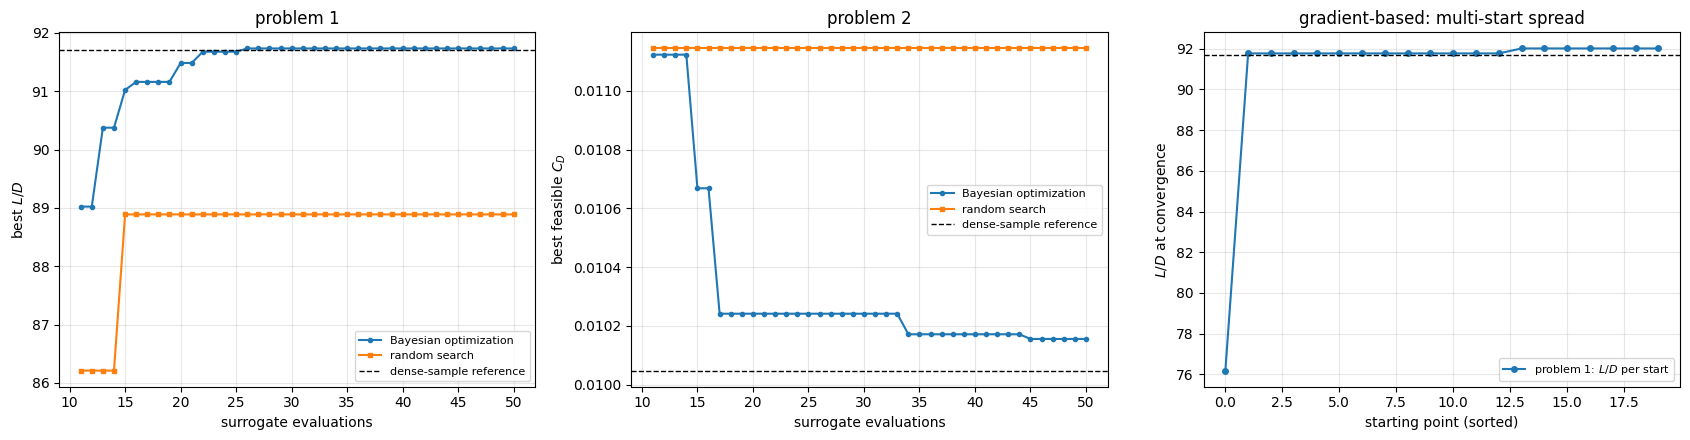

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
ax[0].plot(np.arange(1, len(bo1['history']) + 1) + OPT['n_init'], -bo1['history'], 'o-', ms=3, label='Bayesian optimization')
ax[0].plot(np.arange(1, len(rand1['history']) + 1) + OPT['n_init'], -rand1['history'], 's-', ms=3, label='random search')
ax[0].axhline(ref1['ld'], color='k', ls='--', lw=1, label='dense-sample reference')
ax[0].set_xlabel('surrogate evaluations'); ax[0].set_ylabel('best $L/D$'); ax[0].set_title('problem 1')

ax[1].plot(np.arange(1, len(bo2['history']) + 1) + OPT['n_init'], bo2['history'], 'o-', ms=3, label='Bayesian optimization')
ax[1].plot(np.arange(1, len(rand2['history']) + 1) + OPT['n_init'], rand2['history'], 's-', ms=3, label='random search')
ax[1].axhline(ref2['cd'], color='k', ls='--', lw=1, label='dense-sample reference')
ax[1].set_xlabel('surrogate evaluations'); ax[1].set_ylabel('best feasible $C_D$'); ax[1].set_title('problem 2')

ax[2].plot(np.sort(-grad1['starts']), 'o-', ms=4, label='problem 1: $L/D$ per start')
ax[2].axhline(ref1['ld'], color='k', ls='--', lw=1)
ax[2].set_xlabel('starting point (sorted)'); ax[2].set_ylabel('$L/D$ at convergence')
ax[2].set_title('gradient-based: multi-start spread')
for a in ax:
    a.grid(alpha=0.3); a.legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/convergence.png', dpi=150, bbox_inches='tight'); plt.show()

## 12. Design space and the optima
$L/D$ over camber and thickness at the optimum's camber position, with the Gaussian process standard deviation of $\log C_D$ on the same slice. Training designs are overlaid.

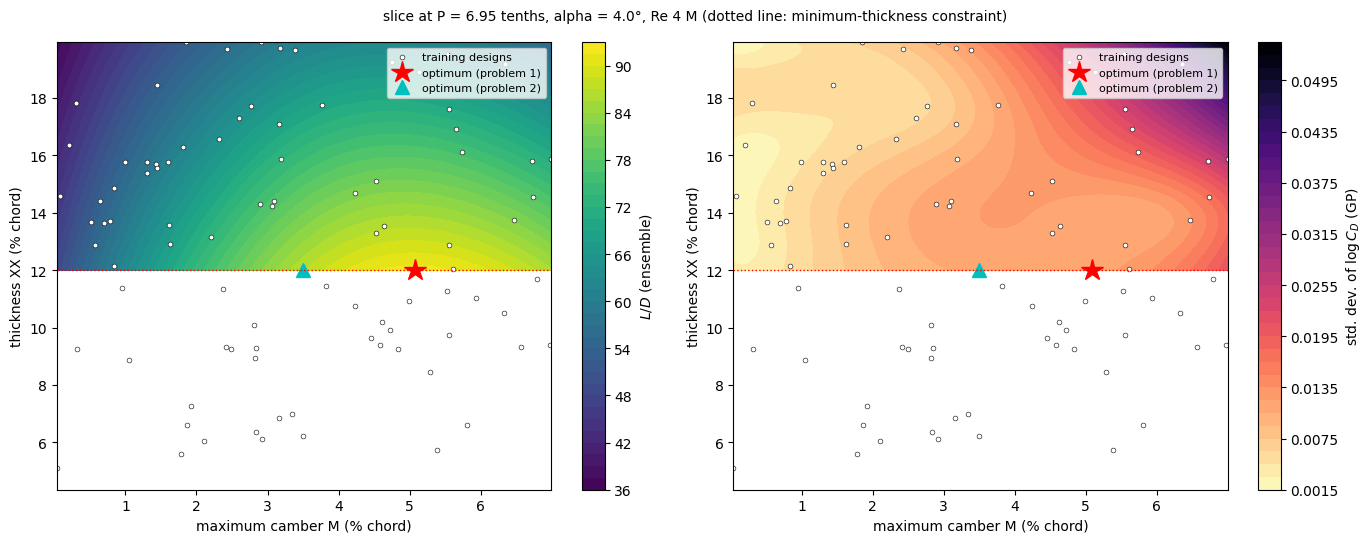

In [ ]:
x_opt = grad1['x']
Mg, Tg = np.meshgrid(np.linspace(lo[0], hi[0], 120), np.linspace(lo[2], hi[2], 120))
grid = np.c_[Mg.ravel(), np.full(Mg.size, x_opt[1]), Tg.ravel()]
cl_g, cd_g = nn_np(grid, aoa=OPT['aoa_p1'])
_, _, _, sd_g = gp_np(np.c_[grid, np.full(len(grid), OPT['aoa_p1'])])

fig, ax = plt.subplots(1, 2, figsize=(14, 5.5))
for a, F, lab, cmap in ((ax[0], (cl_g / cd_g).reshape(Mg.shape), '$L/D$ (ensemble)', 'viridis'),
                        (ax[1], sd_g.reshape(Mg.shape), 'std. dev. of $\\log C_D$ (GP)', 'magma_r')):
    cf = a.contourf(Mg, Tg, F, levels=40, cmap=cmap)
    plt.colorbar(cf, ax=a, label=lab)
    a.scatter(tr4[:, 0], tr4[:, 2], s=12, c='white', edgecolor='k', lw=0.4, label='training designs')
    a.plot(x_opt[0], x_opt[2], 'r*', ms=16, label='optimum (problem 1)')
    a.plot(opt2.loc['gradient-based', 'M'], opt2.loc['gradient-based', 'XX'], 'c^', ms=10, label='optimum (problem 2)')
    a.axhline(OPT['t_min'], color='r', ls=':', lw=1)
    a.set_xlabel('maximum camber M (% chord)'); a.set_ylabel('thickness XX (% chord)')
    a.legend(fontsize=8, loc='upper right')
fig.suptitle(f'slice at P = {x_opt[1]:.2f} tenths, alpha = {OPT["aoa_p1"]}°, Re 4 M '
             f'(dotted line: minimum-thickness constraint)', fontsize=10)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/design_space.png', dpi=150, bbox_inches='tight'); plt.show()

## 13. Optimised geometries
The optimised airfoils, generated with `airfrans.naca_generator`, against NACA 2412 as a familiar reference.

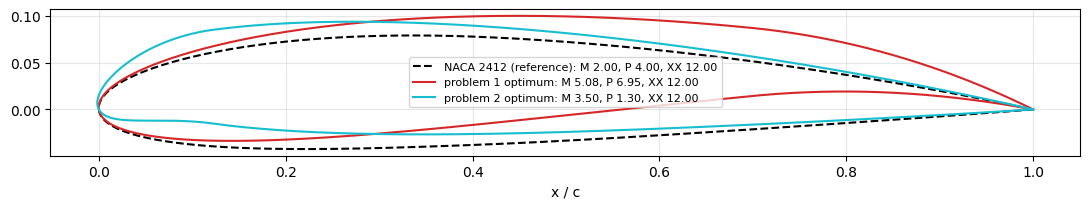

In [ ]:
fig, ax = plt.subplots(figsize=(11, 3.4))
shapes = [('NACA 2412 (reference)', [2.0, 4.0, 12.0], 'k', '--'),
          (f"problem 1 optimum", list(grad1['x'][:3]), 'tab:red', '-'),
          (f"problem 2 optimum", list(grad2['x'][:3]), 'tab:cyan', '-')]
for lab, p, col, ls in shapes:
    prof = naca_generator(np.array(p), nb_samples=400, verbose=False)
    ax.plot(prof[:, 0], prof[:, 1], color=col, ls=ls,
            label=f'{lab}: M {p[0]:.2f}, P {p[1]:.2f}, XX {p[2]:.2f}')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_xlabel('x / c')
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/optimised_shapes.png', dpi=150, bbox_inches='tight'); plt.show()

## 14. Nearest evidence in the dataset
The optimum cannot be verified with new CFD here, so the closest available evidence is used: the training and test simulations nearest to the optimised design, with their true coefficients. Agreement is reassuring but not proof; Phase 4 examines the question properly.

In [ ]:
all_forces = pd.concat([train_forces.assign(split=np.where(train_forces['name'].isin(VAL_NAMES), 'val', 'train')),
                        pd.read_csv(os.path.join(DRIVE_DIR if USE_DRIVE else '/content',
                                                 'phase2/test_forces.csv')).assign(split='test')],
                       ignore_index=True)
four = all_forces[[len(parse_name(n)[2]) == 3 for n in all_forces['name']]].copy()
P4 = np.array([parse_name(n)[2] for n in four['name']])
four[['M', 'P', 'XX']] = P4

for lab, x, aoa in (('problem 1', grad1['x'][:3], OPT['aoa_p1']), ('problem 2', grad2['x'][:3], grad2['x'][3])):
    d_shape = np.linalg.norm((P4 - x) / span, axis=1)
    d_cond = np.abs(four['aoa'].values - aoa) / 20 + np.abs(four['re'].values - OPT['re']) / 4e6
    near = four.assign(d=d_shape + d_cond).nsmallest(3, 'd')
    cl_p, cd_p = [], []
    for _, r in near.iterrows():
        c, d = nn_np(np.array([[r['M'], r['P'], r['XX']]]), aoa=r['aoa'])
        cl_p.append(c[0]); cd_p.append(d[0])
    near = near.assign(CL_pred=cl_p, CD_pred=cd_p)
    print(f'\n{lab} optimum: M {x[0]:.2f}, P {x[1]:.2f}, XX {x[2]:.2f}, alpha {aoa:.2f}°')
    print(near[['split', 'M', 'P', 'XX', 'aoa', 're', 'true_cl', 'CL_pred', 'true_cd', 'CD_pred', 'd']]
          .to_string(index=False, float_format=lambda v: f'{v:.4f}'))


problem 1 optimum: M 5.08, P 6.95, XX 12.00, alpha 4.00°
split      M      P      XX    aoa           re  true_cl  CL_pred  true_cd  CD_pred      d
  val 5.5220 6.1160 11.2750 6.7850 2940738.4123   1.3513   1.3683   0.0155   0.0146 0.5671
train 6.4700 5.9140 13.7550 4.8480 4924846.4116   1.2457   1.2284   0.0143   0.0146 0.6062
  val 5.9390 6.4810 11.0390 4.1760 2232589.2971   1.1576   1.1848   0.0145   0.0126 0.6358

problem 2 optimum: M 3.50, P 1.30, XX 12.00, alpha 4.40°
split      M      P      XX    aoa           re  true_cl  CL_pred  true_cd  CD_pred      d
 test 2.7000 0.0000 12.7420 0.8300 3979572.1941   0.0920   0.1333   0.0087   0.0096 0.4222
 test 2.4240 2.4110 10.9280 3.3330 4595774.8410   0.6070   0.6029   0.0091   0.0091 0.4633
train 2.3710 0.0000 11.3330 7.0080 4296513.2833   0.7597   0.7798   0.0103   0.0109 0.4659


## 15. Saved artefacts

In [ ]:
summary = dict(opt=OPT, bounds=dict(M=list(BOUNDS3[0]), P=list(BOUNDS3[1]), XX=list(BOUNDS3[2]),
                                     alpha=list(OPT['aoa_bounds'])),
               reference=dict(problem1=dict(design=ref1['design'].tolist(), ld=float(ref1['ld'])),
                              problem2=dict(design=ref2['design'].tolist(), cd=float(ref2['cd']))),
               problem1=opt1.reset_index().to_dict(orient='records'),
               problem2=opt2.reset_index().to_dict(orient='records'),
               cost=cost.reset_index().to_dict(orient='records'))
with open(f'{OUT_DIR}/phase3_summary.json', 'w') as f:
    json.dump(summary, f, indent=2, default=float)
np.savez(f'{OUT_DIR}/optima.npz', p1_grad=grad1['x'], p1_bo=bo1['x'], p1_rand=rand1['x'],
         p1_ref=ref1['design'], p2_grad=grad2['x'], p2_bo=bo2['x'], p2_rand=rand2['x'],
         p2_ref=ref2['design'], bo1_hist=bo1['history'], bo2_hist=bo2['history'])
for p in sorted(glob.glob(f'{OUT_DIR}/*')):
    print(f'{os.path.getsize(p) / 1e6:8.2f} MB  {p}')

    0.12 MB  /content/drive/MyDrive/airfrans/phase3/convergence.png
    0.17 MB  /content/drive/MyDrive/airfrans/phase3/design_space.png
    0.00 MB  /content/drive/MyDrive/airfrans/phase3/optima.npz
    0.09 MB  /content/drive/MyDrive/airfrans/phase3/optimised_shapes.png
    0.01 MB  /content/drive/MyDrive/airfrans/phase3/phase3_summary.json


## Summary
Two optimization problems are solved on the same neural-network surrogate by three routes: Bayesian optimization, random search at equal budget, and multi-start gradient descent using automatic-differentiation sensitivities. A dense random sample supplies the surrogate's own optimum, so search error and surrogate error are kept separate. Every optimum is re-evaluated with the independent Gaussian-process surrogate, with its predictive interval, and located relative to the training designs.

The gradient-based route needs neither an adjoint solver nor finite differences: the surrogate is differentiable, and the parameterisation is written so that sensitivities propagate from the design variables through the shape descriptor to the predicted coefficients.

**Results.** Automatic-differentiation sensitivities agree with central finite differences to seven
decimal places. Maximising L/D at Re = 4 × 10⁶ and α = 4°:

| method | surrogate evaluations | best L/D | vs. dense-sample reference |
|---|---|---|---|
| Bayesian optimization | 50 | 91.73 | −0.03 % |
| random search, equal budget | 50 | 88.89 | +3.07 % |
| gradient-based, 20 starts | 176 (8.8 per start) | 92.01 | −0.33 % |

Lift-constrained drag minimisation behaves the same way, reaching CD = 0.00992 with the constraint
active at exactly CL = 0.800, against 0.0102 for Bayesian optimization and 0.0111 for random search.
Both principled methods reach the surrogate's own optimum; random search does not, which is why the
control matters.

A single gradient-based search costs roughly a sixth of the Bayesian run, but one of the twenty
starts converged to L/D = 76 instead of 92, so restarts are necessary and the global-coverage cost
that Bayesian optimization pays explicitly is still paid, just differently.

Two findings matter more than the optima themselves. First, the two methods found *different*
designs with nearly identical predicted performance (camber 6.98 against 5.08, a 0.3 % difference in
L/D), so the objective has a flat ridge and the optimum is not a single point. When the independent
Gaussian process evaluates those two designs it rates them 91.3 and 87.7: a 4 % disagreement, more
than ten times the margin the optimizers were competing over. Surrogate accuracy, not search
quality, is the binding constraint. Second, both optima sit exactly on the 12 % minimum-thickness
bound, and L/D rises steadily as thickness falls, so the answer is set by the structural constraint
rather than by aerodynamics. Both optima lie close to existing training designs (0.13 and 0.26 in
normalised design units) and at conditions well inside the training range, so they are
interpolation.

**Next : Phase 4:** whether these optima can be trusted. Where they sit relative to the training designs, whether the optimum survives retraining on data subsets, how accuracy and predicted uncertainty behave when the training band is deliberately narrowed, and the worst-predicted case in the dataset, where separated flow raises drag far above anything the surrogate has seen.